# TRABAJO SEMANAL N°3: ANÁLISIS DE FOURIER
### Alumna: Maylen Monterde
### INTRODUCCIÓN:
Una señal senoidal continua en el tiempo $x(t) = A\cdot sin(2 \cdot \pi \cdot f_0 \cdot t)$, tiene una Transformada de Fourier compuesta por dos deltas en $\pm w_0$:
$$X(w)=\frac{A}{2j} \cdot [\delta(w-w_0)-\delta(w+w_0)]$$
Para trabajar con esto, primero se muestrea la señal en el tiempo (multiplicando por un tren de impulsos), obteniendo la DTFT:
$$X(e^{-j \omega})=\sum_{n=-\infty}^{\infty} x[n]\cdot e^{-j \omega n}$$
Con esta expresión se obtiene el dominio frecuencial continuo y periódico. Como se busca que sea un espectro discreto, se utiliza una DFT:
$$X[k]=\sum_{n=0}^{N-1} x[n]\cdot e^{-j \frac{2\pi}{N} kn}$$
Donde la DFT no es más que muestrear la DTFT en N muestras o frecuencias discretas, separadas por la resolución espectral (sin normalizar): 
$$\Delta f= \frac{f_s}{N}$$
Donde la frecuencia senoidal es: $f_0=k_0\cdot \Delta f$, con $k_0$ entero. En este caso, las muestras de la DFT caen exactamente sobre la frecuencia de la señal, obteniéndose un único par de deltas (bien definidas) tal como se espera del espectro teórico continuo. 
Sin embargo en la práctica nunca se dispone de infinitas muestras, se trabaja con una cantidad finita de N muestras. Esta duración finita hace que el espectro real no esté conformado por deltas 'perfectas', sino por picos con una cierta anchura y lóbulos laterales decrecientes. Cuando $k_0$ es un entero, las muestras discretas de la DFT caen justo donde ese pico es máximo por lo que se observa una única linea espectral. En cambio, cuando $k_0$ no es un entero (como será en dos casos de esta práctica) los bins vecinos absorben parte de la energía de esos lóbulos laterales. Esto se lo conoce como derrame espectral: la energía que debería concentrarse en una única componente se reparte entre varios bins cercanos a la frecuencia real de la señal.

**PARSEVAL:**
La potencia de una señal es la misma tanto en el dominio del tiempo como en el de las frecuencias, solo cambia la manera de observarla (como se distribuye).
$$P(n)=\frac{1}{N}\cdot \sum_{n=0}^{N-1} x[n]^2$$
Esto implica que, aunque el derrame espectral distribuya la energía entre varios bins en lugar de concentrarla en uno solo, la suma total de la energía en el dominio de la frecuencia siempre coincide con la potencia de la señal en el dominio del tiempo. Por eso dos senoidales de frecuencias muy cercanas (una con $k_0$ entero y otra desintonizada) pueden mostrar espectros visualmente muy distintos, sin que esto implique una diferencia real en su potencia total.

**ZERO PADDING**
El zero padding consiste en agregar una cantidad de ceros al final de la señal ($9N$ ceros), sin modificar su contenido. Esto aumenta el número total de muestras a $N_{pad}=10N$, lo que reduce la separación entre bins de la DFT:

$$\Delta f_{pad}=\frac{f_s}{N_{pad}}=\frac{f_s}{10\cdot N}$$

De esta manera se logra interpolar con mayor densidad la misma DTFT continua, que no cambia porque la señal original es la misma. Esto permite visualizar con mayor detalle la forma real en los casos con derrame espectral. Una observación es que el zero padding no elimina el derrame ni reduce el ancho del lóbulo principal sino que solamente permite observar con mayor resolución el mismo fenómeno.
### CONSIGNA:
Se generarán tres señales senoidales con distintos valores de $k_0$ y la potencia normalizada, buscando graficarlas y compararlas. Luego se verificará la potencia unitaria en cada caso y por último, se repetirá el experimento con zero padding.


### RESOLUCIÓN:
1- En esta tarea semanal, generé funciones para simplificar código:

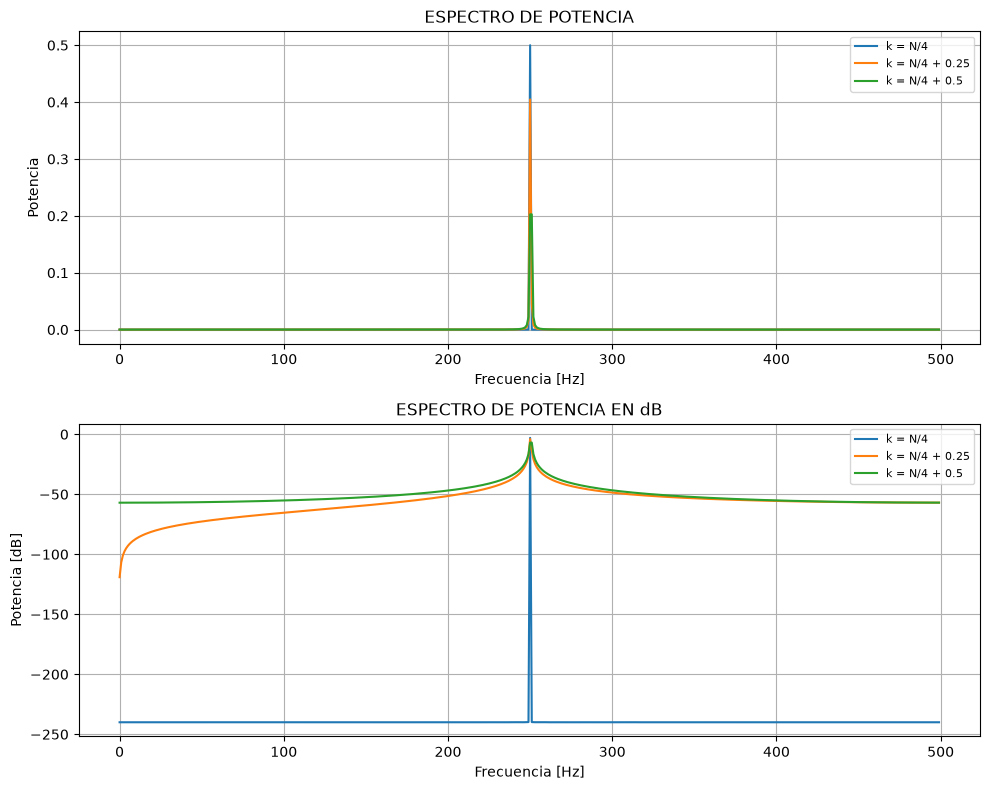

In [9]:
## TS3 - ANÁLISIS DE FOURIER
#%% LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt

#%% FUNCIONES 
# FUNCIÓN SENOIDAL
def funcion_sen(A=1, Vmed=0, ff=1, phi=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs
    xx = A * np.sin(2 * np.pi * ff * tt + phi) + Vmed
    return tt, xx

# FUNCIÓN QUE GENERA LAS 3 SEÑALES SEGÚN k0
def generador_k(Amplitud, Vmed, phi, N, fs):
    k0 = [N/4, N/4 + 0.25, N/4 + 0.5]
    xx_seno = []
    fft_seno = []
    modulo_seno = []

    for k in k0:
        ff = k * (fs / N)
        tt, xx = funcion_sen(Amplitud, Vmed, ff, phi, N, fs)
        fft = np.fft.fft(xx) / N
        modulo = np.abs(fft)

        xx_seno.append(xx)
        fft_seno.append(fft)
        modulo_seno.append(modulo)

    return tt, k0, xx_seno, fft_seno, modulo_seno
#%% PARÁMETROS GENERALES
Ps = 1 # potencia de la senoidal (normalizada a 1W)
Amplitud = np.sqrt(2*Ps)
Vmed = 0
phi = 0
N = 1000
fs = 1000

#%% LLAMO A LA SEÑAL SENOIDAL
tt, k0, xx_seno, fft_seno, modulo_seno = generador_k(Amplitud, Vmed, phi, N, fs)

#%% FRECUENCIAS HASTA NYQUIST
# Para graficar en el dominio de la frecuencia
frecuencias = np.fft.fftfreq(N, 1/fs)
corte = N // 2
frec_nyquist = frecuencias[:corte]

#%% a) GRAFICO COMPARATIVO
etiquetas = ['k = N/4', 'k = N/4 + 0.25', 'k = N/4 + 0.5']

plt.figure(1, figsize=(10,8))
plt.subplot(2,1,1)
plt.title("ESPECTRO DE POTENCIA")

plt.subplot(2,1,2)
plt.title("ESPECTRO DE POTENCIA EN dB")

for i in range(len(k0)):
    modulo = modulo_seno[i]

    plt.subplot(2,1,1)
    plt.plot(frec_nyquist, (modulo[:corte])**2, label=etiquetas[i])

    plt.subplot(2,1,2)
    plt.plot(frec_nyquist, 20*np.log10(modulo[:corte] + 1e-12), label=etiquetas[i])
    

plt.subplot(2,1,1)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia")
plt.legend(fontsize=8)
plt.grid(True)

plt.subplot(2,1,2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()


Al comparar los tres casos, se observa claramente el efecto del desparrame frecuencial predicho en la introducción. Con $k_0=N/4$ ,entero, el espectro muestra una única línea espectral bien definida, ya que la muestra de la DFT cae exactamente sobre la frecuencia de la señal. En cambio, con $k_0=N/4+0,25$ y $k_0=N/4+0,5$, la energía ya no se concentra en un solo bin sino que se distribuye entre varios bins vecinos, generando un derrame espectral. Este efecto es más marcado en el caso de $k_0=N/4+0,5$, donde el desparrame respecto al bin más cercano es máxima, por lo que la energía se reparte de forma más simétrica entre ambos lados. En el gráfico en dB se aprecia con mayor claridad, ya que permite visualizar los lóbulos laterales de menor amplitud que en escala lineal quedan opacados por el pico principal.

2- Verificación de Parseval:

In [10]:
#%% b) VERIFICACIÓN DE PARSEVAL
for i in range(len(k0)):
    potencia_tiempo = np.mean(xx_seno[i]**2)
    potencia_frecuencia = np.sum(np.abs(fft_seno[i])**2)
    print(f"{etiquetas[i]}: potencia tiempo = {potencia_tiempo:.3f}  |  " f"potencia frecuencia (Parseval) = {potencia_frecuencia:.3f}")


k = N/4: potencia tiempo = 1.000  |  potencia frecuencia (Parseval) = 1.000
k = N/4 + 0.25: potencia tiempo = 0.999  |  potencia frecuencia (Parseval) = 0.999
k = N/4 + 0.5: potencia tiempo = 1.000  |  potencia frecuencia (Parseval) = 1.000


Los valores obtenidos de potencia en el dominio temporal y en el dominio frecuencial resultaron iguales en los tres casos analizados confirmando experimentalmente la identidad de Parseval. Si bien el derrame espectral modifica la forma en la que la energía se distribuye entre los distintos bins de frecuencia, la potencia total de la señal se mantiene constante e igual a la unidad en los tres casos (debido a que se normalizó $A=\sqrt{2P_s}$ con $P_s=1W$).

3- Aplico zero padding:

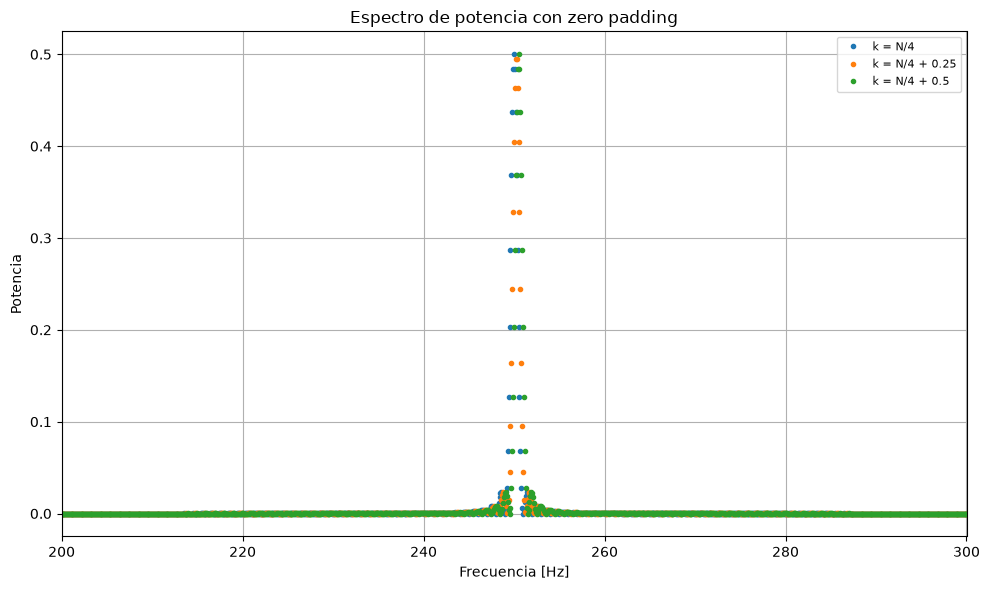

In [11]:
#%% c) ZERO PADDING
zeros = np.zeros(9*N)
N_pad = N + 9*N
frecuencias_pad = np.fft.fftfreq(N_pad, 1/fs)
corte_pad = N_pad // 2
frec_nyquist_pad = frecuencias_pad[:corte_pad]

xx_seno_pad = []
fft_seno_pad = []

for i in range(len(k0)):
    xx_pad = np.concatenate((xx_seno[i], zeros))
    fft_pad = (1/N) * np.fft.fft(xx_pad)
    xx_seno_pad.append(xx_pad)
    fft_seno_pad.append(fft_pad)

plt.figure(figsize=(10,6))
for i in range(len(k0)):
    plt.plot(frec_nyquist_pad, (np.abs(fft_seno_pad[i][:corte_pad]))**2, ".", label=etiquetas[i])

plt.title("Espectro de potencia con zero padding")
plt.xlabel("Frecuencia [Hz]"); plt.ylabel("Potencia")
plt.legend(fontsize=8); plt.grid(True)
plt.xlim(200, 300)
plt.tight_layout()
plt.show()

Al agregar $9N$ ceros al final de cada señal se logró reducir la separación entre bins de los distintos casos, lo que permitió visualizar con mucho mayor detalle la forma real del espectro alrededor del pico principal. En el caso de $k_0=N/4$ se sigue observando una única componente bien definida, mientras que en los otros casos se aprecia con claridad la forma de los lóbulos del derrame espectral, que antes del zero padding se veían muestreados en apenas uno o dos bins. Es importante remarcar que el zero padding no elimina ni reduce el derrame espectral, sino que únicamente aumenta la resolución con la que se visualiza el mismo fenómeno, actuando como una interpolación de la DTFT.

En conclusión, los resultados obtenidos cumplen con lo esperado teóricamente. Cuanto mayor es la desintonía de $k_0$ respecto al bin entero más cercano, mayor es el derrame espectral observado; por eso $k_0=N/4 + 0,5$ mostró un desparramo más marcado mientras que $k_0=N/4$ no presentó desparrame alguno. Luego, gracias al uso de zero padding, se pudo observar con mayor detalle gráfico este fenómeno, ya que al reducir $\Delta f$ se logra interpolar" la forma real del espectro subyacente. Para cerrar, al calcular la potencia mediante la identidad de Parseval se verificó que la potencia total se mantiene igual (≈1W, tal como se normalizó) en los tres casos: esto confirma que el derrame espectral no implica una pérdida de energía, sino simplemente una distribución distinta de la misma potencia entre varias componentes de frecuencia.